In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from typing import List, Tuple

In [68]:
DOMAIN_NAME = 'blocksworld'
TS_DIR = 'TS_Per_noisy'
TS_VERSION = 'v1'


FOLDER_PATH = f'../testsets/{TS_VERSION}/{TS_DIR}/{DOMAIN_NAME}/report/'
FILE_NAME = 'overall-report.csv'

In [69]:
# Read data from CSV file with ";" as delimiter
noise_5_df = pd.read_csv(f'{FOLDER_PATH}blocksworld-noisy_5/{FILE_NAME}', delimiter=';')
noise_10_df = pd.read_csv(f'{FOLDER_PATH}blocksworld-noisy_10/{FILE_NAME}', delimiter=';')
noise_20_df = pd.read_csv(f'{FOLDER_PATH}blocksworld-noisy_20/{FILE_NAME}', delimiter=';')
noise_30_df = pd.read_csv(f'{FOLDER_PATH}blocksworld-noisy_30/{FILE_NAME}', delimiter=';')

In [70]:
# For each dataframe, calculate the min, max, mean, and std of the 'Noise applied' column
# Also, track the percentage of problems without noise applied (i.e., 'Noise applied' == 0)
# and with full noise applied (i.e., 'Noise applied' == 1)
def calculate_noise_stats(df: pd.DataFrame):
    tot_problems = len(df)
    min_noise = df['Noise applied'].min()
    max_noise = df['Noise applied'].max()
    mean_noise = df['Noise applied'].mean()
    std_noise = df['Noise applied'].std()
    no_noise_pct = (df['Noise applied'] == 0).mean() * 100
    full_noise_pct = (df['Noise applied'] == 1).mean() * 100
    return tot_problems, min_noise, max_noise, mean_noise, std_noise, no_noise_pct, full_noise_pct

noise_5_stats = calculate_noise_stats(noise_5_df)
noise_10_stats = calculate_noise_stats(noise_10_df)
noise_20_stats = calculate_noise_stats(noise_20_df)
noise_30_stats = calculate_noise_stats(noise_30_df)

In [71]:
def build_summary_df(
    noise_levels: List[str],
    stats: List[Tuple[int, float, float, float, float, float, float]]
) -> pd.DataFrame:
    summary_data = {
        'Noise Level': noise_levels,
        'Total Problems': [stat[0] for stat in stats],
        'Min Noise': [stat[1] for stat in stats],
        'Max Noise': [stat[2] for stat in stats],
        'Mean Noise': [stat[3] for stat in stats],
        'Std Noise': [stat[4] for stat in stats],
        '% No Noise': [f"{stat[5]:.2f}%" for stat in stats],
        '% Full Noise': [f"{stat[6]:.2f}%" for stat in stats]
    }
    return pd.DataFrame(summary_data)

In [72]:
summary_df = build_summary_df(
    noise_levels=['5%', '10%', '20%', '30%'],
    stats=[noise_5_stats, noise_10_stats, noise_20_stats, noise_30_stats]
)
summary_df

,Noise Level,Total Problems,Min Noise,Max Noise,Mean Noise,Std Noise,% No Noise,% Full Noise
0,5%,1076,0.0,1.0,0.047917,0.113762,73.70%,0.37%
1,10%,1076,0.0,1.0,0.098743,0.174612,60.41%,1.58%
2,20%,1076,0.0,1.0,0.204128,0.237446,39.50%,4.09%
3,30%,1076,0.0,1.0,0.294501,0.271722,29.37%,6.04%


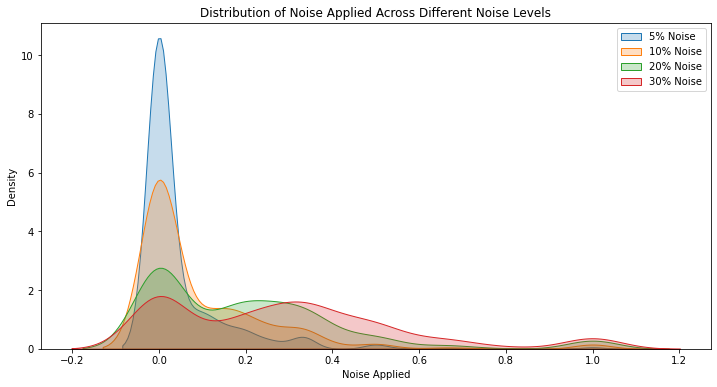

In [73]:
# Display the distribution of 'Noise applied' for each noise level using seaborn using boxplots
plt.figure(figsize=(12, 6))
sns.kdeplot(noise_5_df['Noise applied'], label='5% Noise', fill=True)
sns.kdeplot(noise_10_df['Noise applied'], label='10% Noise', fill=True)
sns.kdeplot(noise_20_df['Noise applied'], label='20% Noise', fill=True)
sns.kdeplot(noise_30_df['Noise applied'], label='30% Noise', fill=True)
plt.title('Distribution of Noise Applied Across Different Noise Levels')
plt.xlabel('Noise Applied')
plt.ylabel('Density')
plt.legend()
plt.show()

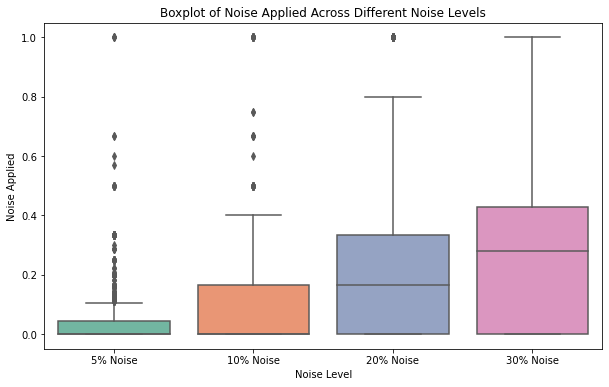

In [74]:
# Display the distribution of 'Noise applied' for each noise level using seaborn using boxplots
# Colored boxplots for better visualization
tmp_df = pd.concat([
    noise_5_df.assign(Noise_Level='5% Noise'),
    noise_10_df.assign(Noise_Level='10% Noise'),
    noise_20_df.assign(Noise_Level='20% Noise'),
    noise_30_df.assign(Noise_Level='30% Noise'),
])
plt.figure(figsize=(10, 6))
sns.boxplot(x='Noise_Level', y='Noise applied', data=tmp_df, palette='Set2')
plt.title('Boxplot of Noise Applied Across Different Noise Levels')
plt.xlabel('Noise Level')
plt.ylabel('Noise Applied')

plt.show()

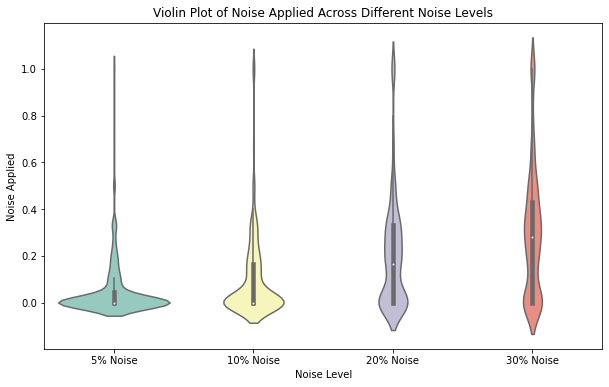

In [75]:
# Display the distribution of 'Noise applied' for each noise level using seaborn using violin plots
plt.figure(figsize=(10, 6))
sns.violinplot(x='Noise_Level', y='Noise applied', data=tmp_df, palette='Set3')
plt.title('Violin Plot of Noise Applied Across Different Noise Levels')
plt.xlabel('Noise Level')
plt.ylabel('Noise Applied')
plt.show()

In [76]:
# Count number of problems and percentage for each noise level with '# Actions' <= 2
def count_low_action_problems(df: pd.DataFrame, threshold: int = 2):
    return (df['# Actions'] <= threshold).sum()

low_action_5 = count_low_action_problems(noise_5_df)
low_action_10 = count_low_action_problems(noise_10_df)
low_action_20 = count_low_action_problems(noise_20_df)
low_action_30 = count_low_action_problems(noise_30_df)

low_action_summary_df = pd.DataFrame({
    'Noise Level': ['5%', '10%', '20%', '30%'],
    'Problems with <= 2 Actions': [low_action_5, low_action_10, low_action_20, low_action_30],
    'Percentage': [
        f"{(low_action_5 / noise_5_stats[0]) * 100:.2f}%",
        f"{(low_action_10 / noise_10_stats[0]) * 100:.2f}%",
        f"{(low_action_20 / noise_20_stats[0]) * 100:.2f}%",
        f"{(low_action_30 / noise_30_stats[0]) * 100:.2f}%"
    ]
})
low_action_summary_df

,Noise Level,Problems with <= 2 Actions,Percentage
0,5%,260,24.16%
1,10%,260,24.16%
2,20%,260,24.16%
3,30%,260,24.16%


In [77]:
# Count number of problems and percentage for each noise level and for each observation percentage, with '# Actions' <= 2
# You can extract observation percentage from the 'Instance' column. For example, within '10/blocksworld_p001804_hyp=5_10', the observation percentage is 10%
def extract_observation_percentage(instance: str) -> str:
    return f"{instance.split('/')[0]}%"

def count_low_action_by_observation(df: pd.DataFrame, threshold: int = 2):
    df['Observation_Percentage'] = df['Instance'].apply(extract_observation_percentage)
    grouped = df[df['# Actions'] <= threshold].groupby('Observation_Percentage').size().reset_index(name='Count')
    total_grouped = df.groupby('Observation_Percentage').size().reset_index(name='Total')
    merged = pd.merge(grouped, total_grouped, on='Observation_Percentage')
    merged['Percentage'] = (merged['Count'] / merged['Total']) * 100

    # If no problems exist for a certain observation percentage, ensure it is represented with 0 count
    all_obs_percentages = df['Observation_Percentage'].unique()
    for obs in all_obs_percentages:
        if obs not in merged['Observation_Percentage'].values:
            merged = pd.concat([merged, pd.DataFrame({'Observation_Percentage': [obs], 'Count': [0], 'Total': [len(df[df['Observation_Percentage'] == obs])], 'Percentage': [0.0]})], ignore_index=True)

    return merged

low_action_by_obs_5 = count_low_action_by_observation(noise_5_df)
low_action_by_obs_10 = count_low_action_by_observation(noise_10_df)
low_action_by_obs_20 = count_low_action_by_observation(noise_20_df)
low_action_by_obs_30 = count_low_action_by_observation(noise_30_df)

# Combine all into a single dataframe for better visualization
low_action_by_obs_5['Noise Level'] = '5%'
low_action_by_obs_10['Noise Level'] = '10%'
low_action_by_obs_20['Noise Level'] = '20%'
low_action_by_obs_30['Noise Level'] = '30%'
combined_low_action_by_obs = pd.concat([
    low_action_by_obs_5,
    low_action_by_obs_10,
    low_action_by_obs_20,
    low_action_by_obs_30
])
combined_low_action_by_obs = combined_low_action_by_obs[['Noise Level', 'Observation_Percentage', 'Count', 'Total', 'Percentage']]
combined_low_action_by_obs

,Noise Level,Observation_Percentage,Count,Total,Percentage
0,5%,10%,198,246,80.487805
1,5%,30%,51,246,20.731707
2,5%,50%,10,246,4.065041
3,5%,70%,1,246,0.406504
4,5%,100%,0,92,0.000000
0,10%,10%,198,246,80.487805
1,10%,30%,51,246,20.731707
2,10%,50%,10,246,4.065041
3,10%,70%,1,246,0.406504
4,10%,100%,0,92,0.000000
